In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

1. The sales amount of each transaction is given. Visualize the probability distribution of sales values around their mean.


2. The number of orders placed per customer is recorded. Visualize the probability of a customer placing exactly  orders, where  ranges from 0–10.


3. The profit column is converted into profit/loss outcomes. Visualize the probability of making a profit vs. a loss in a single order.


4. Delivery times (in days) are recorded. Visualize the probability density of delivery times, focusing on values around the average delivery time.


5. Count the number of orders received each day. Visualize the probability of receiving exactly  orders in a day.


6. Consider whether a discount was given on an order (yes/no). Visualize the probability distribution of orders with and without discounts.


In [ ]:
filepath = "/content/drive/MyDrive/Superstore.csv"
df =  pd.read_csv(filepath,encoding="latin1")

In [ ]:
df.head()
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
pd.set_option('display.max_columns', None)
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


1. The sales amount of each transaction is given. Visualize the probability distribution of sales values around their mean.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson, bernoulli

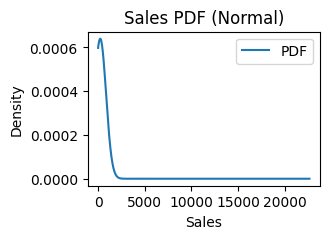

In [ ]:
mu, sigma = df['Sales'].mean(), df['Sales'].std()
x = np.linspace(df['Sales'].min(), df['Sales'].max(), 1000)

pdf_vals = norm.pdf(x, mu, sigma)
plt.figure(figsize=(3,2))
plt.plot(x, pdf_vals, label="PDF")
plt.title("Sales PDF (Normal)")
plt.xlabel("Sales"); plt.ylabel("Density");
plt.legend();
plt.show();


2. The number of orders placed per customer is recorded. Visualize the probability of a customer placing exactly orders, where ranges from 0–10.

Customer ID
AA-10315     5
AA-10375     9
AA-10480     4
AA-10645     6
AB-10015     3
            ..
XP-21865    11
YC-21895     5
YS-21880     8
ZC-21910    13
ZD-21925     5
Name: Order ID, Length: 793, dtype: int64

 6.316519546027743

 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


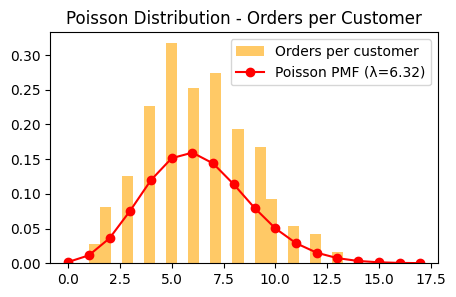

In [ ]:
# Count unique orders per customer
orders_per_customer = df.groupby("Customer ID")["Order ID"].nunique()
print(orders_per_customer)

# λ = mean orders
lam = orders_per_customer.mean()
print("\n",lam)

# Range of values
x = np.arange(0, orders_per_customer.max()+1)
pmf = poisson.pmf(x, lam)
print("\n",x)

plt.figure(figsize=(5,3))
plt.hist(orders_per_customer, bins=30, density=True, alpha=0.6, color="orange", label="Orders per customer")
plt.plot(x, pmf, 'r-', marker='o', label=f"Poisson PMF (λ={lam:.2f})")
plt.title("Poisson Distribution - Orders per Customer")
plt.legend()
plt.show()

3. The profit column is converted into profit/loss outcomes. Visualize the probability of making a profit vs. a loss in a single order.

0       1
1       1
2       1
3       0
4       1
       ..
9989    1
9990    1
9991    1
9992    1
9993    1
Name: Profit, Length: 9994, dtype: int64


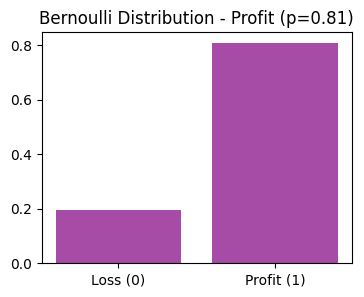

In [ ]:
# Convert profit to binary
profit_binary = df["Profit"].apply(lambda x: 1 if x > 0 else 0)
print(profit_binary)

# Probability of success (profit > 0)
p = profit_binary.mean()

# Values
x = [0, 1]
pmf = bernoulli.pmf(x, p)

plt.figure(figsize=(4,3))
plt.bar(x, pmf, tick_label=["Loss (0)", "Profit (1)"], color="purple", alpha=0.7)
plt.title(f"Bernoulli Distribution - Profit (p={p:.2f})")
plt.show()

4. Delivery times (in days) are recorded. Visualize the probability density of delivery times, focusing on values around the average delivery time.

In [ ]:
# Calculate delivery time in days
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')
df['Delivery Time'] = (df['Ship Date'] - df['Order Date']).dt.days

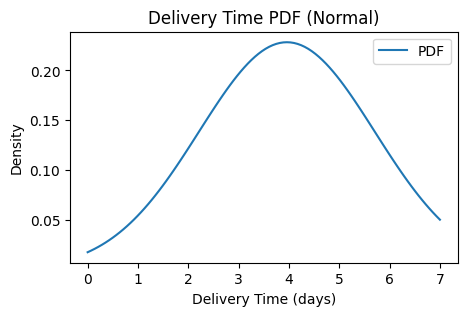

In [ ]:
# Fit a normal distribution to the delivery times
mu_delivery, sigma_delivery = df['Delivery Time'].mean(), df['Delivery Time'].std()

# Generate x values for the PDF
x_delivery = np.linspace(df['Delivery Time'].min(), df['Delivery Time'].max(), 100)

# Calculate the PDF values
pdf_delivery = norm.pdf(x_delivery, mu_delivery, sigma_delivery)

# Plot the PDF
plt.figure(figsize=(5, 3))
plt.plot(x_delivery, pdf_delivery, label="PDF")
plt.title("Delivery Time PDF (Normal)")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Density")
plt.legend()
plt.show()

5. Count the number of orders received each day. Visualize the probability of receiving exactly orders in a day.


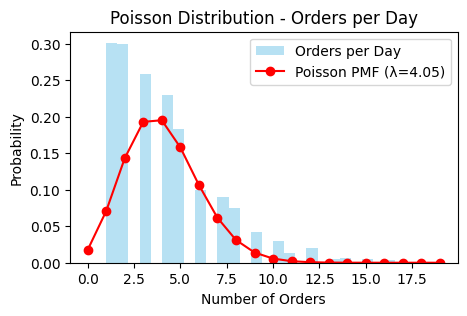

In [ ]:
# Count orders per day
orders_per_day = df.groupby('Order Date')['Order ID'].nunique()

# Calculate lambda (mean orders per day)
lam_day = orders_per_day.mean()

# Range of values to plot (up to max orders per day)
x_day = np.arange(0, orders_per_day.max() + 1)

# Calculate Poisson PMF
pmf_day = poisson.pmf(x_day, lam_day)

# Plot the distribution
plt.figure(figsize=(5, 3))
plt.hist(orders_per_day, bins=30, density=True, alpha=0.6, color='skyblue', label='Orders per Day')
plt.plot(x_day, pmf_day, 'r-', marker='o', label=f'Poisson PMF (λ={lam_day:.2f})')
plt.title('Poisson Distribution - Orders per Day')
plt.xlabel('Number of Orders')
plt.ylabel('Probability')
plt.legend()
plt.show()

6. Consider whether a discount was given on an order (yes/no). Visualize the probability distribution of orders with and without discounts.

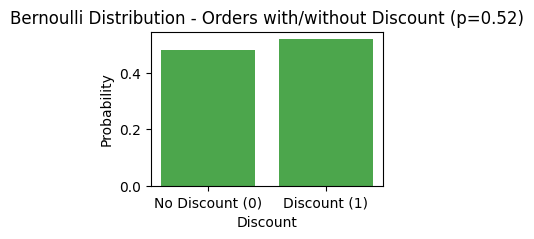

In [ ]:
# Create binary column for discount presence
discount_binary = df['Discount'].apply(lambda x: 1 if x > 0 else 0)

# Probability of having a discount
p_discount = discount_binary.mean()

# Values for Bernoulli distribution (0 for no discount, 1 for discount)
x_discount = [0, 1]
pmf_discount = bernoulli.pmf(x_discount, p_discount)

# Plot the distribution
plt.figure(figsize=(3,2))
plt.bar(x_discount, pmf_discount, tick_label=['No Discount (0)', 'Discount (1)'], color='green', alpha=0.7)
plt.title(f'Bernoulli Distribution - Orders with/without Discount (p={p_discount:.2f})')
plt.xlabel('Discount')
plt.ylabel('Probability')
plt.show()